# Práctica Final TI24 - Modelo Principal: Random Forest (Bagging)
## Tema: Bagging - Random Forests
### Dataset: Loan Default Prediction

### Objetivo de este notebook

Implementación y evaluación del modelo principal **Random Forest**, algoritmo
de ensamble basado en **Bagging** (*Bootstrap Aggregating*).


## 2. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, RocCurveDisplay
)


## 3. Carga y preprocesamiento del dataset

Se carga el dataset y se aplica el mismo preprocesamiento definido en `02_preprocessing.ipynb`.


In [4]:
url = "https://raw.githubusercontent.com/soledadaldunate/repositorio-TI24-Aldunate/main/data/raw/Loan_default.csv"
df = pd.read_csv(url)
df = df.drop(columns=["LoanID"])

# Encoding de variables categóricas
variables_categoricas = ["Education", "EmploymentType", "MaritalStatus",
                         "HasMortgage", "HasDependents", "LoanPurpose", "HasCoSigner"]
for col in variables_categoricas:
    df[col] = LabelEncoder().fit_transform(df[col])

# Split
X = df.drop(columns=["Default"])
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
variables_numericas = ["Age", "Income", "LoanAmount", "CreditScore",
                       "MonthsEmployed", "NumCreditLines", "InterestRate",
                       "LoanTerm", "DTIRatio"]
scaler = StandardScaler()
X_train[variables_numericas] = scaler.fit_transform(X_train[variables_numericas])
X_test[variables_numericas] = scaler.transform(X_test[variables_numericas])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Distribución de clases en y_train (%):")
print(y_train.value_counts(normalize=True).round(3) * 100)


X_train: (204277, 16)
X_test : (51070, 16)
Distribución de clases en y_train (%):
Default
0    88.4
1    11.6
Name: proportion, dtype: float64


## 4. Entrenamiento del modelo Random Forest

### Decisiones de diseño

- `n_estimators=200`: suficientes árboles para estabilizar predicciones.
- `max_depth=12`: limita profundidad para controlar sobreajuste.
- `class_weight="balanced"`: compensa el desbalance 88.4% / 11.6% detectado en el EDA.
- `max_features="sqrt"`: en cada nodo se evalúan $\sqrt{p}$ variables aleatorias.
- `n_jobs=-1`: usa todos los núcleos disponibles.


In [5]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Modelo Random Forest entrenado correctamente.")


Modelo Random Forest entrenado correctamente.


## 5. Predicciones

In [6]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]


## 6. Resultados: Accuracy y F1-score

In [7]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nReporte de clasificación completo:\n")
print(classification_report(y_test, y_pred, target_names=["No Default (0)", "Default (1)"]))


Accuracy : 0.7736
F1-score : 0.3597

Reporte de clasificación completo:

                precision    recall  f1-score   support

No Default (0)       0.93      0.80      0.86     45139
   Default (1)       0.27      0.55      0.36      5931

      accuracy                           0.77     51070
     macro avg       0.60      0.68      0.61     51070
  weighted avg       0.85      0.77      0.80     51070



**Interpretación:** Dado el desbalance de clases (88.4%/11.6%), el accuracy puede ser engañoso — un modelo que siempre prediga "No Default" obtendría ~88% sin ser útil. El **F1-score de la clase Default (1)** es la métrica más relevante, ya que mide el balance entre detectar correctamente los incumplimientos (sensibilidad) y no generar demasiadas falsas alarmas (precisión).

## 7. Matriz de confusión

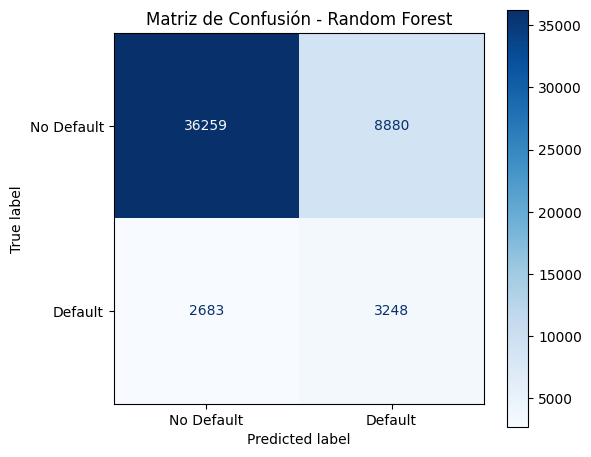

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"]).plot(
    ax=ax, cmap="Blues", values_format="d"
)
plt.title("Matriz de Confusión - Random Forest")
plt.tight_layout()
plt.show()


**Interpretación:** Los **falsos negativos** (clientes que incumplirán pero el modelo predijo que no) son el error más costoso en este problema, pues representan riesgo de crédito no detectado.

## 8. Curva ROC y AUC

<Figure size 600x500 with 0 Axes>

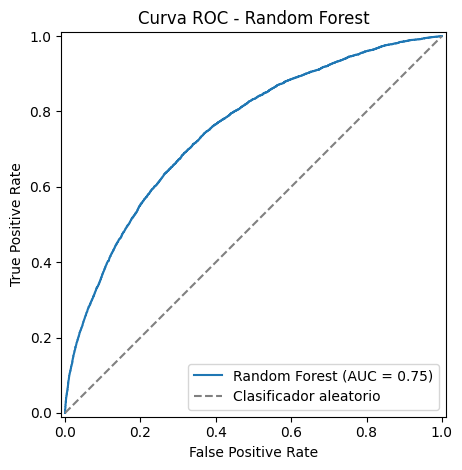

AUC: 0.7507


In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name="Random Forest").plot()
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")


**Interpretación:** Un AUC cercano a 1 indica excelente capacidad discriminativa entre clientes que incumplirán y los que no, independientemente del umbral de decisión elegido.

## 9. Importancia de variables

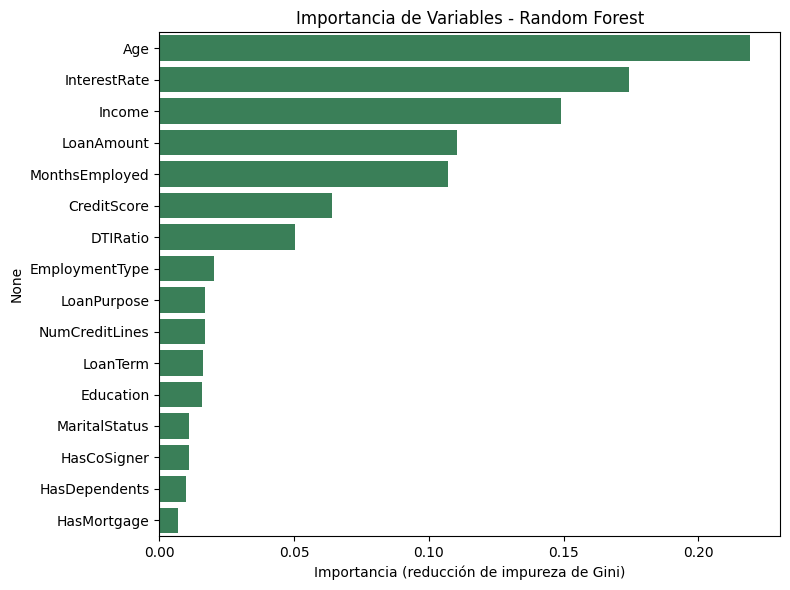

Age               0.219315
InterestRate      0.174106
Income            0.148932
LoanAmount        0.110631
MonthsEmployed    0.106977
CreditScore       0.064050
DTIRatio          0.050403
EmploymentType    0.020356
LoanPurpose       0.016907
NumCreditLines    0.016805
LoanTerm          0.016396
Education         0.015898
MaritalStatus     0.011081
HasCoSigner       0.011054
HasDependents     0.009989
HasMortgage       0.007100
dtype: float64


In [10]:
importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importancias.values, y=importancias.index, color="seagreen")
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia (reducción de impureza de Gini)")
plt.tight_layout()
plt.show()

print(importancias)


**Interpretación:** Las variables con mayor importancia son las que más contribuyen a separar clientes que incumplen de los que no. Se esperan como más relevantes variables financieras como `Income`, `LoanAmount`, `InterestRate` y `CreditScore`, consistente con la teoría de scoring crediticio.